In [16]:
import numpy as np
from matplotlib import pyplot as plt
import sys
np.set_printoptions(threshold=sys.maxsize)

from src.initial_data import initial_data
from src.integrators import solve_ODE
from src.error import wass_2_approx

# Configuration


In [17]:
m = 200

h = .0025
moll_eps = 4 * h**(.99)
xi_eps = 4 * h**(.99)

t_max = 1.5
t_step = 10**(-4)

# Parameters for random blob methods
alg = 2
num_batches = 2
ratio = 2

# Function definitions


In [18]:
# The external potential
def V(x):
    return np.where(x <= 0, x, 0)

# Gradient of velocity field
def grad_V(x):
    return np.where(x <= 0, -1, 0)
        
# Distribution of our initial data
def rho_0(x):
    return np.where((-1 <= x <= -1/2) | (0 <= x <= 1/2), 1, 0)

# 2nd derivative of Moreau-Yosida envelope
def f_double_prime_epsilon(x):
    return m * x**(m - 2)

# Exact solution
def exact(t, x): 
    if t <= 1/2:
        return np.where(((- 1 + t <= x) & (x < -1/2 + t)) | ((x >= 0) & (x <= 1/2)), 1, 0)
    if t >= 1/2:
        t = t - 1/2
        a_t = 1 - 1/2 * np.exp(-t)
        return np.where((a_t - 1 <= x) & (x <= a_t), 1, 0)

# Plot


In [19]:
def xi(x):
    denom = (2 * np.pi * (xi_eps**2))**(1 / 2)
    arg = - (x**2) / (2 * (xi_eps**2))
    return np.exp(arg) / denom

def smooth(input, m_vals, part_sol):
    return np.dot(xi(input[:, None] - part_sol), m_vals)

def plot(particle_sol, m_vals):
    plt.rcParams.update({'font.size': 20})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    x_vals = np.arange(- 3.5, 3.5, .01)
    times = np.array([0, .25, .5, t_max])
    colors = plt.cm.viridis(np.linspace(0, 1, times.size))
    for i in range(times.size):
        # Plot particle solution
        y_vals = smooth(x_vals, m_vals, particle_sol[int(times[i] / t_step)])
        lab = rf'$t = {round(times[i], 3)}$'
        plt.plot(x_vals, y_vals, '--', linewidth=5, label = lab, color = colors[i])

        # Plot exact solution
        y_vals = exact(times[i], x_vals)
        plt.plot(x_vals, y_vals, linewidth=1, color=colors[i])

        plt.title(rf"$t = {times[i]}$")
        plt.xlabel("Position")
        plt.ylabel("Height")
        plt.ylim(0, 1.2)
        plt.xlim(-1.5, 1.5)
        plt.show()

# Main method


N = 402.
Time step 1000.
Time step 2000.
Time step 3000.
Time step 4000.
Time step 5000.
Time step 6000.
Time step 7000.


/Users/clairemurphy/Desktop/Published Code v2/1d/src/kernel.py:7: RuntimeWarning: overflow encountered in square
  arg = - (y**2) / 2
/Users/clairemurphy/Desktop/Published Code v2/1d/src/kernel.py:14: RuntimeWarning: overflow encountered in square
  return - y * np.exp(- y**2 / 2) / denom


Time step 8000.
Time step 9000.
Time step 10000.
Time step 11000.
Time step 12000.
Time step 13000.
Time step 14000.
Time step 15000.
--- 20.08991003036499 seconds ---


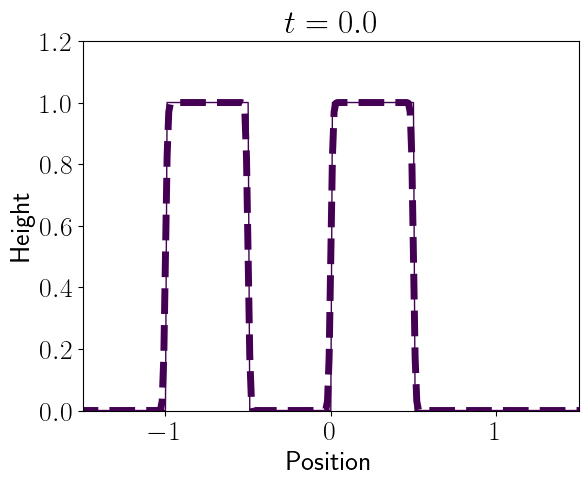

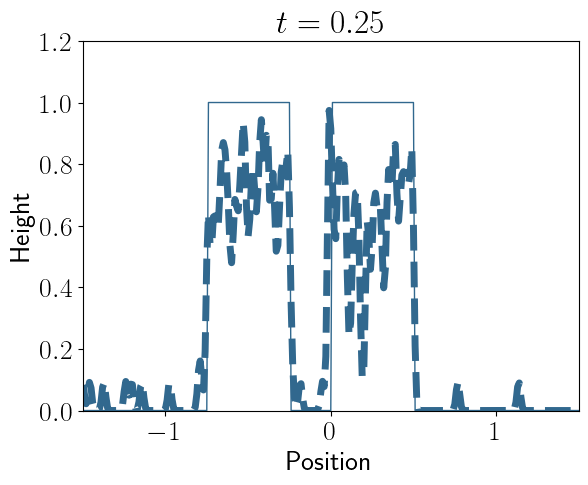

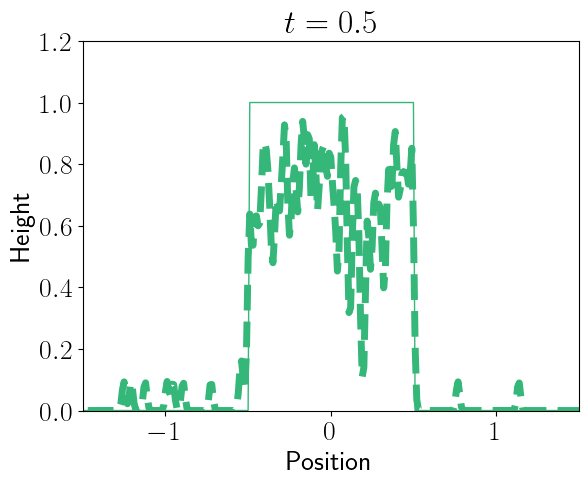

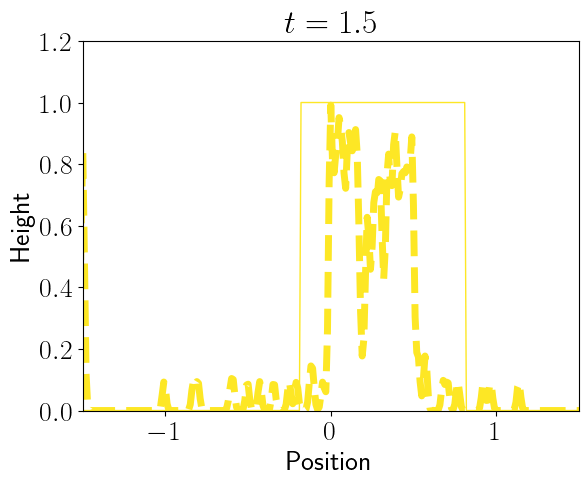

Error = 1.7408910638092223.


In [20]:
x0, m_vals = initial_data(rho_0, 1.5, h)
part_sol, runtime = solve_ODE(x0, m_vals, alg, ratio, num_batches, moll_eps, f_double_prime_epsilon, grad_V, t_step, t_max, 3)
plot(part_sol, m_vals)
plt.show()

def func(x):
    return exact(t_max, x)
error = wass_2_approx(part_sol[-1], m_vals, func, 1.02, .005)
print("Error = " + str(error) + ".")